<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/Tarefa13incompleta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 13 — Normal, t de Student, qui-quadrado e F de Fisher

**Integrantes:**

- Drielly Mathias Albertti — nº 16831084
- Kawana Ganeo de Carvalho — nº 14669691
- Melyssa Ponce Lopes — nº 16831017

---


**Fonte da base:** UCI Machine Learning Repository – Iris Dataset             
**Link:** https://archive.ics.uci.edu/dataset/53/iris                       
**Instituição responsável pelo repositório:** University of California, Irvine (UCI)  
**Autor associado à base:** R. A. Fisher

As **variáveis quantitativas** da base correspondem as medidas morfológicas das plantas, expressas em cm: comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala.





##1. Normal
A distribuição Normal é uma distribuição contínua caracterizada por uma curva simétrica em torno de sua média.  

**Função:**

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
\exp\left[-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right]
$$

em que:

* \(x\) representa um possível valor da variável contínua;
* (μ) representa a média da distribuição;
* (σ) representa o desvio-padrão, com (σ>0);
* (σ^2) representa a variância;
* (π) é a constante matemática pi;
* (e) é a base dos logaritmos naturais.

Na implementação da SciPy, a distribuição Normal é representada por `scipy.stats.norm`, sendo `loc` utilizado para representar a média e `scale` para representar o desvio-padrão. E as funções como `pdf`, `cdf`, `sf` e `ppf` representam, respectivamente, densidade, probabilidade acumulada, probabilidade na cauda superior e quantis.

**Referências:** SciPy Documentation – `scipy.stats.norm`;  
 NIST/SEMATECH e-Handbook of Statistical Methods.

A distribuição Normal será utilizada como modelo para uma característica morfológica contínua das plantas da base Iris. Será utilizado o **comprimento da sépala das 50 plantas de *Iris setosa***.

Nesse caso, o comprimento da sépala é uma medida obtida diretamente de um organismo. Já a distribuição Normal é um modelo estatístico utilizado para representar a distribuição desses valores.

A partir das 50 observações de *Iris setosa*, serão estimados a média e o desvio-padrão, que serão utilizados como parâmetros do modelo Normal.  



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
import pandas as pd

# Baixando a base diretamente do repositório oficial da UCI para evitar erros de arquivo ausente
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Ordem correta das colunas do Iris original:
# 1. sepal length, 2. sepal width, 3. petal length, 4. petal width
colunas = [
    "Comprimento da sépala",
    "Largura da sépala",
    "Comprimento da pétala",
    "Largura da pétala",
    "Espécies"
]

iris = pd.read_csv(
    url,
    header=None,
    names=colunas
)

iris.head()

,Comprimento da sépala,Largura da sépala,Comprimento da pétala,Largura da pétala,Espécies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


###1.1 Curvas:

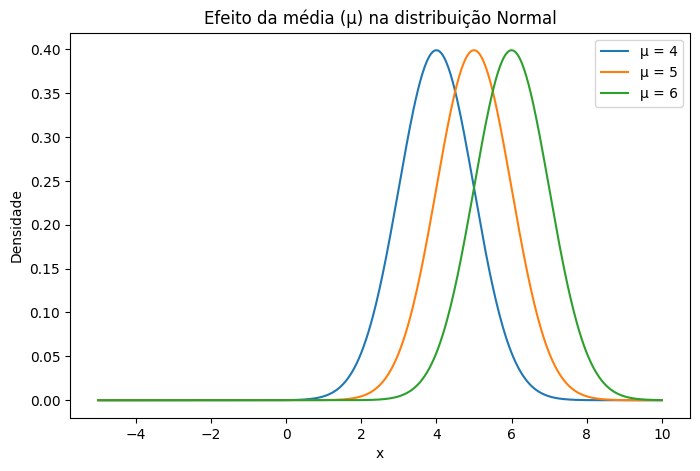

In [6]:
x = np.linspace(-5, 10, 500)

plt.figure(figsize=(8, 5))

for mu in [4, 5, 6]:
    y = stats.norm.pdf(x, loc=mu, scale=1)
    plt.plot(x, y, label=f"μ = {mu}")

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito da média (μ) na distribuição Normal")
plt.legend()
plt.show()

Mantendo o desvio-padrão constante, o aumento da média desloca toda a curva horizontalmente para a direita, enquanto a diminuição da média desloca a curva para a esquerda. A forma e a dispersão da curva permanecem iguais.

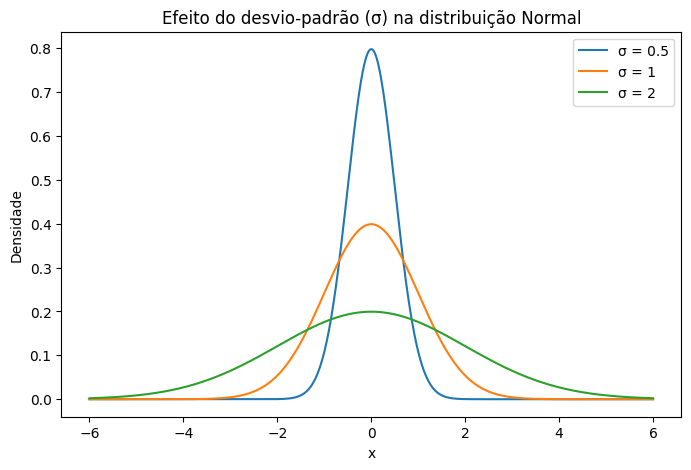

In [7]:
x = np.linspace(-6, 6, 500)

plt.figure(figsize=(8, 5))

for sigma in [0.5, 1, 2]:
    y = stats.norm.pdf(x, loc=0, scale=sigma)
    plt.plot(x, y, label=f"σ = {sigma}")

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Efeito do desvio-padrão (σ) na distribuição Normal")
plt.legend()
plt.show()

Mantendo a média constante, valores maiores de \(σ) aumentam a dispersão dos valores em torno da média. A curva fica mais larga e seu pico diminui. Valores menores de (σ) produzem uma curva mais concentrada e com pico mais elevado. A distribuição Normal permanece simétrica.

A utilização da distribuição Normal exige que a variável seja contínua e que a aproximação pela curva Normal seja biologicamente e estatisticamente razoável.

Uma limitação importante é que a base possui somente 50 observações de cada espécie. Além disso, as plantas presentes na base não devem ser consideradas como uma amostra representativa de todas as plantas das respectivas espécies. Dessa forma, as probabilidades calculadas representam o modelo ajustado aos dados disponíveis e não uma estimativa universal para a espécie.

##2. t de Student
A distribuição t de Student é uma distribuição contínua utilizada em situações envolvendo estatísticas padronizadas relacionadas à média, especialmente quando a variância populacional é desconhecida.

**Função:**

$$
f(t)=
\frac{\Gamma\left(\frac{\nu+1}{2}\right)}
{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)}
\left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}
$$

em que:

* (t) representa um valor da estatística t;
* (ν) representa os graus de liberdade;
* (Γ) representa a função gama;
* (ν>0).

Diferentemente do comprimento da sépala, que é uma medida biológica, o valor de \(t\) é uma **estatística calculada a partir de uma ou mais amostras**.

Na SciPy, a distribuição é implementada por `scipy.stats.t`, sendo os graus de liberdade especificados pelo parâmetro `df`.

**Referências:** SciPy Documentation – `scipy.stats.t`;  
NIST/SEMATECH e-Handbook of Statistical Methods.



**Exemplo:**
- *Iris setosa:* 50 plantas
- *Iris versicolor:* 50 plantas
- Variável: Comprimento da sépala  

$$
t = \frac{\bar{X}_1-\bar{X}_2}
{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}
$$

Os graus de liberdade são estimados pela aproximação de **Welch-Satterthwaite**.

Assim, o que terá distribuição t sob as condições do modelo é a estatística padronizada, e não os comprimentos individuais.

###2.1 Curvas:

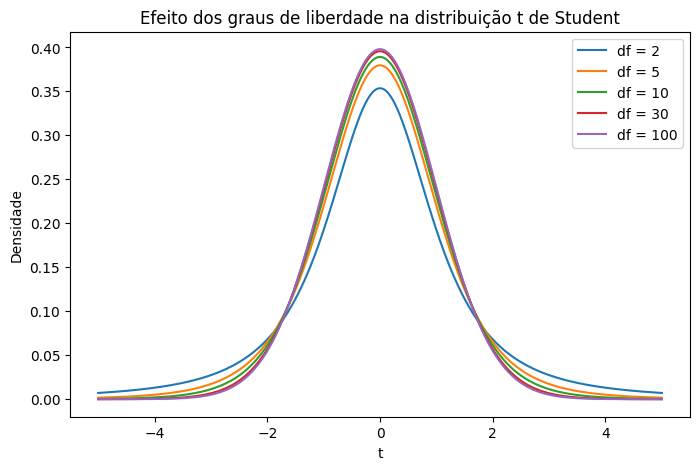

In [8]:
x = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 5))

for df in [2, 5, 10, 30, 100]:
    y = stats.t.pdf(x, df=df)
    plt.plot(x, y, label=f"df = {df}")

plt.xlabel("t")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade na distribuição t de Student")
plt.legend()
plt.show()

Com poucos graus de liberdade, a distribuição t apresenta caudas mais pesadas e maior dispersão do que a Normal padrão. À medida que os graus de liberdade aumentam, as caudas ficam menos pesadas e a distribuição se aproxima progressivamente da distribuição Normal padrão.

A utilização da distribuição t depende das condições associadas à estatística utilizada. Como estamos utilizando duas espécies diferentes, cada planta pertence a apenas um dos grupos. A aproximação de Welch permite trabalhar sem assumir igualdade entre as variâncias.

Uma limitação é que as observações da base Iris correspondem a um conjunto específico de plantas e não necessariamente constituem uma amostra aleatória de toda a população das espécies. Portanto, a análise deve ser interpretada no contexto da base utilizada.



##3. Qui-quadrado
A distribuição qui-quadrado é uma distribuição contínua definida para valores não negativos e caracterizada pelos graus de liberdade.

**Função:**

$$
f(x)=
\frac{1}{2^{\nu/2}\Gamma(\nu/2)}
x^{\nu/2-1}e^{-x/2},
\qquad x>0
$$

em que:

* \(x\) representa um valor da estatística qui-quadrado;
* \(ν) representa os graus de liberdade;
* \(Γ) representa a função gama;
* \(e\) é a base dos logaritmos naturais;
* \(ν>0\).

Para uma amostra proveniente de uma população Normal, a estatística associada à variância pode ser expressa como:

$$
\chi^2=\frac{(n-1)S^2}{\sigma_0^2}
$$

com \(ν=n-1\) graus de liberdade.

Em que:
- \(S^2\) = variância calculada a partir das plantas;
- \(n\) = número de plantas;
- \(σ_0^2) = variância de referência;
- \(χ^2\) = estatística resultante.

**Exemplo:**

A medida biológica continua sendo o comprimento da sépala. A quantidade que será relacionada à distribuição qui-quadrado é uma estatística calculada a partir da variância amostral dos comprimentos.

O principal parâmetro é:

$$ \nu = n-1 $$

Para as 50 *Iris setosa*:

ν=50−1=49


###3.1 Curva:

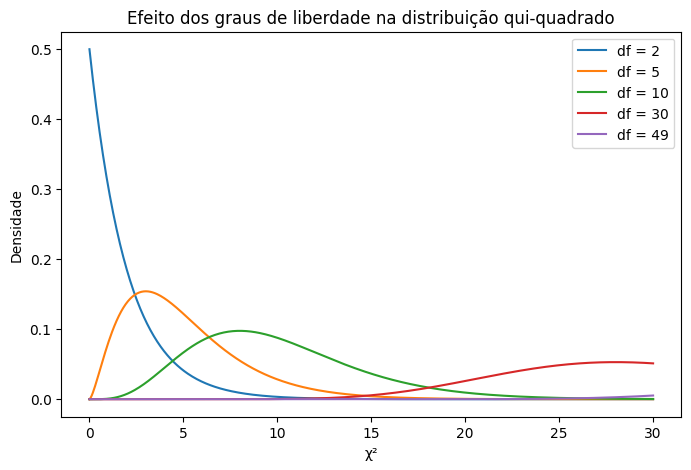

In [9]:
x = np.linspace(0, 30, 500)

plt.figure(figsize=(8, 5))

for df in [2, 5, 10, 30, 49]:
    y = stats.chi2.pdf(x, df=df)
    plt.plot(x, y, label=f"df = {df}")

plt.xlabel("χ²")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade na distribuição qui-quadrado")
plt.legend()
plt.show()

Com poucos graus de liberdade, a distribuição qui-quadrado apresenta forte assimetria à direita. Conforme os graus de liberdade aumentam, a assimetria diminui e a distribuição se torna mais concentrada em torno de valores maiores. A distribuição permanece definida apenas para valores iguais ou superiores a zero.

##4. F de Fisher
A distribuição F de Fisher é uma distribuição contínua utilizada para representar razões entre duas quantidades relacionadas a variâncias. Sua função densidade pode ser escrita como:

$$
f(x)=
\frac{
\left(\frac{\nu_1}{\nu_2}\right)^{\nu_1/2}
x^{\nu_1/2-1}
}{
B\left(\frac{\nu_1}{2},\frac{\nu_2}{2}\right)
\left(1+\frac{\nu_1}{\nu_2}x\right)^{(\nu_1+\nu_2)/2}
},
\qquad x>0
$$

em que:

* \(x\) representa um valor da estatística F;
* \(ν_1\) representa os graus de liberdade do numerador;
* \(ν_2\) representa os graus de liberdade do denominador;
* \(B\) representa a função beta;
* \(\v_1>0\) e \(v_2>0\).

No contexto deste trabalho, a estatística F será construída como uma razão entre duas variâncias amostrais:

$$
F=\frac{S_1^2}{S_2^2}
$$


**Exemplo:**
A variabilidade do comprimento da sépala difere entre *Iris setosa* e *Iris virginica*?

A variável é a mesma, mas temos dois grupos independentes, com cada um possuindo 50 observações individuais.

A estatística será:

$$ F=\frac{S_{\text{virginica}}^2}{S_{\text{setosa}}^2} $$

Então:

$$ \nu_1=50-1=49 $$
$$ \nu_2=50-1=49 $$


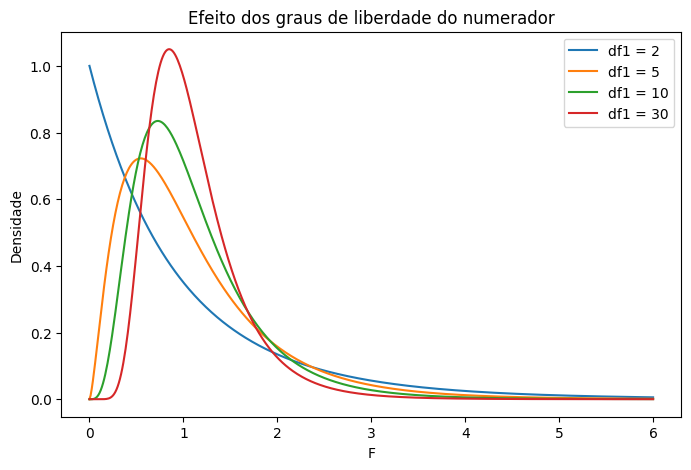

In [10]:
#Variando o grau de liberdade do numerador
x = np.linspace(0, 6, 500)

plt.figure(figsize=(8, 5))

for df1 in [2, 5, 10, 30]:
    y = stats.f.pdf(x, dfn=df1, dfd=20)
    plt.plot(x, y, label=f"df1 = {df1}")

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade do numerador")
plt.legend()
plt.show()

Mantendo os graus de liberdade do denominador constantes, a alteração de \(v_1\) modifica a forma da distribuição, principalmente sua assimetria e concentração. Com poucos graus de liberdade, a distribuição apresenta maior assimetria e uma cauda direita mais pronunciada. Com o aumento de \(v_1\), a distribuição tende a ficar mais concentrada.

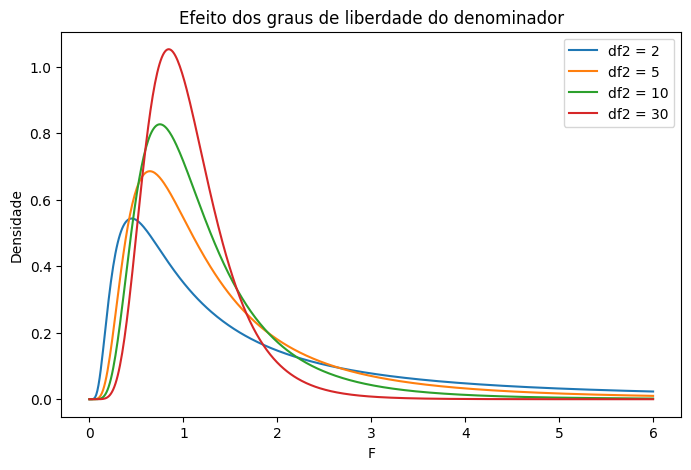

In [11]:
#Variando o grau de liberdade do denominador
x = np.linspace(0, 6, 500)

plt.figure(figsize=(8, 5))

for df2 in [2, 5, 10, 30]:
    y = stats.f.pdf(x, dfn=20, dfd=df2)
    plt.plot(x, y, label=f"df2 = {df2}")

plt.xlabel("F")
plt.ylabel("Densidade")
plt.title("Efeito dos graus de liberdade do denominador")
plt.legend()
plt.show()

Mantendo os graus de liberdade do numerador constantes, a alteração de \(v_2\) também modifica a assimetria e a cauda direita da distribuição. Valores pequenos de \(v_2\) produzem maior dispersão na razão de variâncias, enquanto valores maiores tornam a distribuição mais concentrada.

A utilização da distribuição F para uma razão de variâncias pressupõe que as duas amostras sejam independentes e que as observações de cada grupo sejam provenientes de populações aproximadamente Normais.  

Uma limitação é que a razão de variâncias depende da ordem escolhida para numerador e denominador. Por isso, essa escolha deve ser informada explicitamente. Neste trabalho, será utilizada a variância do comprimento da sépala de *Iris virginica* no numerador e a de *Iris setosa* no denominador.

A distribuição F, portanto, não descreve os comprimentos das sépalas diretamente. Ela descreve o comportamento teórico de uma **razão de variâncias amostrais** sob determinadas condições estatísticas.


##5. Probabilidades com Python
### 5.1 Probabilidades para a distribuição Normal

Será considerado o comprimento da sépala das 50 plantas de *Iris setosa*. A variável é uma medida morfológica contínua, expressa em centímetros, e será modelada por uma distribuição Normal com média de 5,006 cm e desvio-padrão de 0,3525 cm.

**Pergunta biológica:** Qual a probabilidade de uma *Iris setosa* apresentar comprimento da sépala menor ou igual a 5,5 cm?


In [14]:
prob_acumulada = stats.norm.cdf(
    5.5,
    loc=media,
    scale=desvio
)

print(f"P(X ≤ 5,5) = {prob_acumulada:.4f}")
print(f"Probabilidade = {prob_acumulada*100:.2f}%")

P(X ≤ 5,5) = 0.9195
Probabilidade = 91.95%


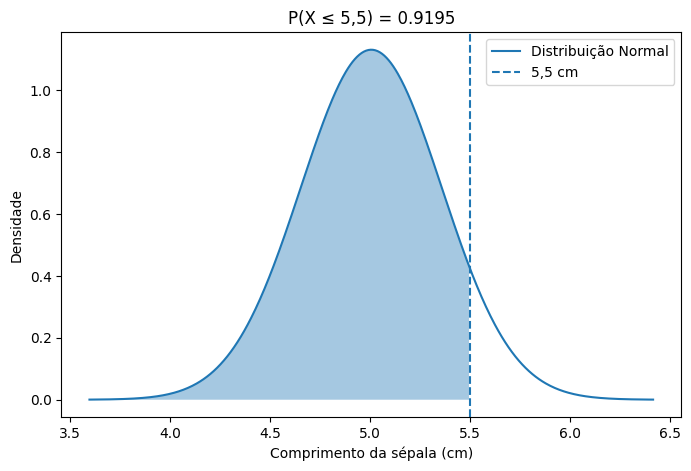

In [15]:
x = np.linspace(media - 4*desvio, media + 4*desvio, 500)
y = stats.norm.pdf(x, loc=media, scale=desvio)

limite = 5.5
x_sombra = x[x <= limite]
y_sombra = stats.norm.pdf(x_sombra, loc=media, scale=desvio)

plt.figure(figsize=(8,5))

plt.plot(x, y, label="Distribuição Normal")

plt.fill_between(
    x_sombra,
    y_sombra,
    alpha=0.4
)

plt.axvline(
    limite,
    linestyle="--",
    label="5,5 cm"
)

plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Densidade")
plt.title(f"P(X ≤ 5,5) = {prob_acumulada:.4f}")
plt.legend()
plt.show()

A área sombreada corresponde à probabilidade acumulada calculada pela função `cdf`. O resultado numérico de aproximadamente 0,9195 corresponde a uma área de aproximadamente 91,95% sob a curva à esquerda de 5,5 cm.

Assim, sob o modelo Normal ajustado aos dados, estima-se uma probabilidade de aproximadamente 91,95% de uma medida de comprimento da sépala de *Iris setosa* ser menor ou igual a 5,5 cm.


##**Referências:**    
SciPy Documentation – `scipy.stats.norm`;          
NIST/SEMATECH e-Handbook of Statistical Methods.